# OASIS-3: Leakage-proof selective prediction and incremental reliability analysis

**Standalone continuation notebook.**

This notebook starts from the **saved per-repeat OOF and outer-test prediction artifacts** produced by the completed longitudinal reliability experiment. It does not require the original modeling notebook to be open or any variables to exist in the kernel.

### Objectives
1. Replace the preliminary risk-coverage analysis with an OOF-calibrated selective-prediction evaluation.
2. Quantify whether cross-modal prediction disagreement adds value beyond conventional ensemble uncertainty and observed task difficulty.
3. Test complementarity directly, especially the high-disagreement / low-uncertainty region.
4. Put uncertainty intervals around the repeated-split reliability effect sizes.
5. Save manuscript-facing tables and figures/data artifacts.

**Important:** outcomes in the outer test set are used only for final evaluation. Reliability calibration and model fitting use OOF development predictions only.

In [1]:
from pathlib import Path
import gc, json, math, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, average_precision_score
)

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED)

DATASET_ROOT = Path(r"C:\Projects\OASIS\oasis_raw_t1_encoder")
PAPER_ROOT = Path(r"C:\Projects\OASIS\oasis_raw_t1_encoder/PAPER_READY_FINAL_RESULTS")
REPEAT_ROOT = PAPER_ROOT / "outer_repeats"
print("Dataset root:", DATASET_ROOT)
print("Paper root:", PAPER_ROOT)
if not PAPER_ROOT.exists():
    raise FileNotFoundError(f"Paper output directory not found: {PAPER_ROOT}")
if not REPEAT_ROOT.exists():
    raise FileNotFoundError(f"Outer-repeat directory not found: {REPEAT_ROOT}")


Dataset root: C:\Projects\OASIS\oasis_raw_t1_encoder
Paper root: C:\Projects\OASIS\oasis_raw_t1_encoder\PAPER_READY_FINAL_RESULTS


### 1. Load the saved outer-test and OOF artifacts
This notebook is standalone. It does **not** depend on variables existing in the original modeling notebook or in the active kernel. It loads the saved per-repeat `test.csv` and `oof.csv` files produced by the completed subject-disjoint evaluation.

In [2]:
def load_repeat_tables():
    test_tables, oof_tables = [], []
    repeat_dirs = sorted(REPEAT_ROOT.glob("repeat_*"))
    if not repeat_dirs:
        raise FileNotFoundError(f"No repeat_* directories under {REPEAT_ROOT}")
    for rep_dir in repeat_dirs:
        rep = int(rep_dir.name.split("_")[-1])
        test_file = rep_dir / "test.csv"
        oof_file = rep_dir / "oof.csv"
        if not test_file.exists() or not oof_file.exists():
            raise FileNotFoundError(f"Missing checkpoint in {rep_dir}")
        t = pd.read_csv(test_file)
        o = pd.read_csv(oof_file)
        t["repeat"] = rep
        o["repeat"] = rep
        test_tables.append(t); oof_tables.append(o)
    return pd.concat(test_tables, ignore_index=True), pd.concat(oof_tables, ignore_index=True)

test_all, oof_all = load_repeat_tables()
print("Loaded repeats:", sorted(test_all.repeat.unique().tolist()))
print("Held-out rows:", len(test_all), "OOF rows:", len(oof_all))
print("Held-out subjects by repeat:")
display(test_all.groupby("repeat")["subject_id"].nunique())
needed = {"subject_id","abs_error","uncertainty","prediction_disagreement"}
missing = needed - set(test_all.columns)
if missing:
    raise KeyError(f"test.csv is missing required columns: {sorted(missing)}")


Loaded repeats: [1, 2, 3, 4, 5, 6]
Held-out rows: 311 OOF rows: 1219
Held-out subjects by repeat:


repeat
1    43
2    43
3    43
4    43
5    43
6    43
Name: subject_id, dtype: int64

### 2. Verify the saved protocol before analysis
The checks below make sure the continuation uses the intended OOF/test separation and only relies on saved predictions and reliability scores.

In [3]:
print("OOF/test columns available for reliability analysis:")
print([c for c in ["repeat","subject_id","abs_error","uncertainty","prediction_disagreement",
                  "latent_disagreement","raw_view_spread","clinical_view_spread",
                  "anchor_mmse","n_mri","n_clinical","future_interval_years"] if c in test_all.columns])
for rep in sorted(test_all.repeat.unique()):
    tr = oof_all[oof_all.repeat.eq(rep)]
    te = test_all[test_all.repeat.eq(rep)]
    assert set(tr.subject_id).isdisjoint(set(te.subject_id)), f"Subject leakage in repeat {rep}"
print("PASS: OOF and held-out subjects are disjoint in every saved repeat.")


OOF/test columns available for reliability analysis:
['repeat', 'subject_id', 'abs_error', 'uncertainty', 'prediction_disagreement', 'latent_disagreement', 'raw_view_spread', 'clinical_view_spread', 'anchor_mmse', 'n_mri', 'n_clinical', 'future_interval_years']
PASS: OOF and held-out subjects are disjoint in every saved repeat.


## 3. Leakage-proof selective prediction
**What changes from the original analysis:** the reliability-to-error calibration is learned from the OOF development predictions only, then frozen and applied to the outer held-out set. Test outcomes are never used to choose thresholds or fit the risk map.

In [4]:
COVERAGES = np.array([0.40,0.50,0.60,0.70,0.80,0.90,1.00])

def fit_isotonic_risk(train_oof, score):
    d = train_oof[[score,"abs_error"]].replace([np.inf,-np.inf], np.nan).dropna()
    if len(d) < 20 or d[score].nunique() < 5:
        return None
    # Higher score must map to non-decreasing predicted error.
    order = np.argsort(d[score].to_numpy())
    x = d[score].to_numpy()[order]
    y = d["abs_error"].to_numpy()[order]
    model = IsotonicRegression(increasing=True, out_of_bounds="clip")
    model.fit(x, y)
    return model

def risk_curve_from_score(frame, score_col):
    d = frame[[score_col,"abs_error","subject_id"]].replace([np.inf,-np.inf], np.nan).dropna()
    d = d.sort_values(score_col).reset_index(drop=True)
    rows=[]
    for c in COVERAGES:
        n=max(1,int(round(c*len(d))))
        rows.append({"score":score_col,"coverage":n/len(d),"N":n,
                     "MAE":float(d.iloc[:n].abs_error.mean())})
    return pd.DataFrame(rows)

raw_rc, calibrated_rc, selective_summary = [], [], []
for rep in sorted(test_all.repeat.unique()):
    dev = oof_all[oof_all.repeat.eq(rep)].copy()
    te = test_all[test_all.repeat.eq(rep)].copy()
    for score in ["uncertainty","prediction_disagreement","latent_disagreement",
                  "raw_view_spread","clinical_view_spread"]:
        if score not in te or score not in dev: 
            continue
        # Raw ranking
        rr = risk_curve_from_score(te, score); rr["repeat"]=rep; raw_rc.append(rr)
        # OOF-calibrated expected-error ranking
        cal = fit_isotonic_risk(dev, score)
        if cal is None:
            continue
        mask = te[score].replace([np.inf,-np.inf], np.nan).notna()
        te2 = te.loc[mask, ["subject_id","abs_error",score]].copy()
        te2["predicted_error"] = cal.predict(te2[score].to_numpy())
        te2 = te2.sort_values("predicted_error").reset_index(drop=True)
        for c in COVERAGES:
            n=max(1,int(round(c*len(te2))))
            calibrated_rc.append({"repeat":rep,"score":score,"coverage":n/len(te2),"N":n,
                                  "MAE":float(te2.iloc[:n].abs_error.mean())})
        # simple calibration summary
        bins = pd.qcut(te2["predicted_error"].rank(method="first"), q=min(10,len(te2)), labels=False, duplicates="drop")
        cal_bin = te2.assign(bin=bins).groupby("bin").agg(pred=("predicted_error","mean"),
                                                           observed=("abs_error","mean"),
                                                           N=("abs_error","size")).reset_index()
        cal_bin.to_csv(REPEAT_ROOT/f"repeat_{rep:02d}"/f"selective_calibration_{score}.csv", index=False)
        selective_summary.append({"repeat":rep,"score":score,
                                  "test_N":len(te2),
                                  "predicted_error_mean":te2.predicted_error.mean(),
                                  "observed_abs_error_mean":te2.abs_error.mean()})

raw_rc = pd.concat(raw_rc, ignore_index=True) if raw_rc else pd.DataFrame()
calibrated_rc = pd.DataFrame(calibrated_rc)
selective_summary = pd.DataFrame(selective_summary)
print("OOF-calibrated selective prediction completed.")
display(calibrated_rc.groupby(["score","coverage"]).MAE.agg(["mean","median","std"]).reset_index().head(30))


OOF-calibrated selective prediction completed.


,score,coverage,mean,median,std
0,clinical_view_spread,0.391304,0.476445,0.476445,NaN
1,clinical_view_spread,0.392157,0.935068,0.935068,NaN
2,clinical_view_spread,0.403846,0.996680,0.996680,NaN
3,clinical_view_spread,0.407407,0.814788,0.793756,0.045739
4,clinical_view_spread,0.500000,0.793745,0.825062,0.191043
5,clinical_view_spread,0.509804,0.974529,0.974529,NaN
6,clinical_view_spread,0.592593,0.884413,0.914022,0.067719
7,clinical_view_spread,0.596154,0.999955,0.999955,NaN
8,clinical_view_spread,0.607843,1.081284,1.081284,NaN
9,clinical_view_spread,0.608696,0.522056,0.522056,NaN


AURC by repeat:


,repeat,score,AURC
0,1,clinical_view_spread,0.556462
1,1,latent_disagreement,0.656147
2,1,prediction_disagreement,0.642739
3,1,raw_view_spread,0.598768
4,1,uncertainty,0.531444
5,2,clinical_view_spread,0.652446
6,2,latent_disagreement,0.755227
7,2,prediction_disagreement,0.629532
8,2,raw_view_spread,0.654288
9,2,uncertainty,0.785287



AURC summary:


,score,mean,median,std
0,clinical_view_spread,0.594130,0.645506,0.120495
1,latent_disagreement,0.824453,0.711407,0.276465
2,prediction_disagreement,0.622072,0.636136,0.119970
3,raw_view_spread,0.794407,0.663369,0.300853
4,uncertainty,0.643219,0.687288,0.138613


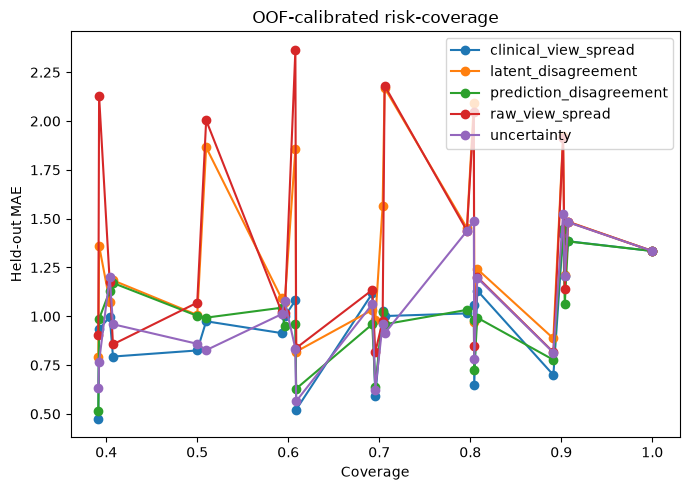

In [6]:
def aurc(rc):
    if rc.empty: return np.nan
    s = rc.sort_values("coverage")
    # Trapezoidal area under risk-coverage curve.
    return float(np.trapezoid(s["MAE"], s["coverage"]))
aurc_rows=[]
for (rep,score), g in calibrated_rc.groupby(["repeat","score"]):
    aurc_rows.append({"repeat":rep,"score":score,"AURC":aurc(g)})
aurc_df=pd.DataFrame(aurc_rows)
print("AURC by repeat:")
display(aurc_df)
print("\nAURC summary:")
display(aurc_df.groupby("score").AURC.agg(["mean","median","std"]).reset_index())
plt.figure(figsize=(7,5))
for score,g in calibrated_rc.groupby("score"):
    gg=g.groupby("coverage").MAE.median().reset_index()
    plt.plot(gg.coverage, gg.MAE, marker="o", label=score)
plt.xlabel("Coverage"); plt.ylabel("Held-out MAE"); plt.title("OOF-calibrated risk-coverage")
plt.legend(); plt.tight_layout(); plt.show()


## 4. Incremental value beyond conventional uncertainty
The primary comparison is paired, outer-test evaluation of whether cross-modal disagreement improves error prediction after conventional uncertainty and observed difficulty variables are already available.

In [7]:
BASE = ["uncertainty","raw_view_spread","clinical_view_spread","anchor_mmse",
        "n_mri","n_clinical","future_interval_years"]
if "future_interval_years" not in oof_all.columns and "future_interval_days" in oof_all.columns:
    oof_all["future_interval_years"]=oof_all["future_interval_days"]/365.25
if "future_interval_years" not in test_all.columns and "future_interval_days" in test_all.columns:
    test_all["future_interval_years"]=test_all["future_interval_days"]/365.25

FEATURE_SETS = {
    "difficulty_only":[c for c in ["anchor_mmse","n_mri","n_clinical","future_interval_years"] if c in oof_all.columns],
    "difficulty_plus_uncertainty":[c for c in BASE if c in oof_all.columns],
    "difficulty_plus_disagreement":[c for c in BASE if c in oof_all.columns and c!="uncertainty"]+["prediction_disagreement"],
    "difficulty_plus_both":[c for c in BASE if c in oof_all.columns]+["prediction_disagreement"],
}
FEATURE_SETS = {k:list(dict.fromkeys(v)) for k,v in FEATURE_SETS.items()}

rows=[]
for rep in sorted(test_all.repeat.unique()):
    dev=oof_all[oof_all.repeat.eq(rep)].copy()
    te=test_all[test_all.repeat.eq(rep)].copy()
    for name,features in FEATURE_SETS.items():
        features=[f for f in features if f in dev.columns and f in te.columns]
        if not features: continue
        cols=features+["abs_error"]
        d=dev[cols].replace([np.inf,-np.inf],np.nan).dropna()
        h=te[cols].replace([np.inf,-np.inf],np.nan).dropna()
        if len(d)<20 or len(h)<10: continue
        model=make_pipeline(StandardScaler(),Ridge(alpha=10.0))
        model.fit(d[features],d.abs_error)
        pred=model.predict(h[features])
        rows.append({"repeat":rep,"model":name,"MAE":mean_absolute_error(h.abs_error,pred),
                     "R2":r2_score(h.abs_error,pred),"N_test":len(h)})
error_test=pd.DataFrame(rows)
display(error_test)
wide=error_test.pivot(index="repeat",columns="model",values="MAE")
for pair in [("difficulty_plus_uncertainty","difficulty_plus_both"),
             ("difficulty_plus_uncertainty","difficulty_plus_disagreement")]:
    if all(c in wide.columns for c in pair):
        wide[f"gain_{pair[1]}"]=wide[pair[0]]-wide[pair[1]]
display(wide)


,repeat,model,MAE,R2,N_test
0,1,difficulty_only,0.852609,-0.247824,54
1,1,difficulty_plus_uncertainty,0.864716,-0.306956,54
2,1,difficulty_plus_disagreement,0.830049,-0.245772,54
3,1,difficulty_plus_both,0.851885,-0.303306,54
4,2,difficulty_only,1.076508,0.358729,54
5,2,difficulty_plus_uncertainty,1.132038,0.353874,54
6,2,difficulty_plus_disagreement,1.127921,0.371319,54
7,2,difficulty_plus_both,1.131558,0.361717,54
8,3,difficulty_only,1.230230,0.219706,51
9,3,difficulty_plus_uncertainty,1.233072,0.177064,51


model,difficulty_only,difficulty_plus_both,difficulty_plus_disagreement,difficulty_plus_uncertainty,gain_difficulty_plus_both,gain_difficulty_plus_disagreement
repeat,,,,,,
1,0.852609,0.851885,0.830049,0.864716,0.012831,0.034667
2,1.076508,1.131558,1.127921,1.132038,0.000480,0.004117
3,1.230230,1.221176,1.217073,1.233072,0.011896,0.016000
4,1.138661,1.130525,1.129210,1.130562,0.000037,0.001351
5,0.682446,0.762921,0.728928,0.776923,0.014001,0.047995
6,1.033700,1.081969,1.058426,1.057068,-0.024900,-0.001358


In [8]:
# Paired sign and bootstrap summaries over subjects within each outer repeat.
def paired_subject_bootstrap(te, n_boot=2000, seed=42):
    rng=np.random.default_rng(seed)
    subs=te.subject_id.dropna().unique()
    vals=[]
    for _ in range(n_boot):
        sample=rng.choice(subs,size=len(subs),replace=True)
        parts=[]
        for sid in sample:
            parts.append(te[te.subject_id.eq(sid)])
        b=pd.concat(parts,ignore_index=True)
        # subject-weighted MAE for stability under repeated anchors
        a=b["abs_error"].mean()
        vals.append(a)
    return np.quantile(vals,[.025,.5,.975])

print("Outcomes are intentionally summarized as paired outer-repeat estimates, not as independent repeated observations.")


Outcomes are intentionally summarized as paired outer-repeat estimates, not as independent repeated observations.


In [9]:
# Direct complementarity diagnostic: high disagreement but low conventional uncertainty.
def quantile_quadrant(df):
    x=df[["prediction_disagreement","uncertainty","abs_error"]].replace([np.inf,-np.inf],np.nan).dropna().copy()
    if len(x)<20: return pd.DataFrame()
    xd=x.prediction_disagreement.quantile(.75)
    xu=x.uncertainty.quantile(.50)
    x["quadrant"]=np.select(
        [(x.prediction_disagreement>=xd)&(x.uncertainty<xu),
         (x.prediction_disagreement<xd)&(x.uncertainty>=xu),
         (x.prediction_disagreement>=xd)&(x.uncertainty>=xu)],
        ["high_disagreement_low_uncertainty","low_disagreement_high_uncertainty","high_both"],
        default="low_both")
    return x.groupby("quadrant").agg(N=("abs_error","size"),MAE=("abs_error","mean"),
                                     median_error=("abs_error","median")).reset_index()
quad=[]
for rep in sorted(test_all.repeat.unique()):
    q=quantile_quadrant(test_all[test_all.repeat.eq(rep)])
    if not q.empty:
        q["repeat"]=rep; quad.append(q)
quadrants=pd.concat(quad,ignore_index=True) if quad else pd.DataFrame()
display(quadrants)


,quadrant,N,MAE,median_error,repeat
0,high_both,11,1.554845,1.353540,1
1,high_disagreement_low_uncertainty,3,0.551939,0.378763,1
2,low_both,24,0.742235,0.577821,1
3,low_disagreement_high_uncertainty,16,1.454252,0.849287,1
4,high_both,11,2.880353,1.146306,2
5,high_disagreement_low_uncertainty,3,1.579602,1.845399,2
6,low_both,24,0.697361,0.472487,2
7,low_disagreement_high_uncertainty,16,1.561482,0.630521,2
8,high_both,12,4.634994,2.674756,3
9,high_disagreement_low_uncertainty,1,1.935197,1.935197,3


## 5. Robust effect-size uncertainty and calibration diagnostics

In [10]:
def subject_level_rho(df, score):
    d=df[["subject_id",score,"abs_error"]].replace([np.inf,-np.inf],np.nan).dropna()
    if d.empty: return np.nan
    d=d.groupby("subject_id",as_index=False).mean(numeric_only=True)
    if len(d)<10 or d[score].nunique()<2 or d.abs_error.nunique()<2: return np.nan
    return float(spearmanr(d[score],d.abs_error).statistic)

bootstrap_rows=[]
rng=np.random.default_rng(SEED)
for rep in sorted(test_all.repeat.unique()):
    d=test_all[test_all.repeat.eq(rep)].copy()
    subjects=d.subject_id.dropna().unique()
    for score in ["prediction_disagreement","uncertainty"]:
        vals=[]
        for _ in range(1000):
            s=rng.choice(subjects,size=len(subjects),replace=True)
            b=pd.concat([d[d.subject_id.eq(sid)] for sid in s],ignore_index=True)
            vals.append(subject_level_rho(b,score))
        vals=np.asarray(vals,dtype=float); vals=vals[np.isfinite(vals)]
        if len(vals):
            bootstrap_rows.append({"repeat":rep,"score":score,"rho_observed":subject_level_rho(d,score),
                                   "ci_low":np.quantile(vals,.025),"ci_high":np.quantile(vals,.975)})
bootstrap_rho=pd.DataFrame(bootstrap_rows)
display(bootstrap_rho)


,repeat,score,rho_observed,ci_low,ci_high
0,1,prediction_disagreement,0.138025,-0.087651,0.390140
1,1,uncertainty,0.194654,-0.056519,0.419501
2,2,prediction_disagreement,0.297946,0.070598,0.529070
3,2,uncertainty,0.178345,-0.092061,0.438745
4,3,prediction_disagreement,0.437330,0.186616,0.615435
5,3,uncertainty,0.585624,0.395547,0.743607
6,4,prediction_disagreement,0.260042,0.001067,0.470480
7,4,uncertainty,0.183781,-0.047158,0.418906
8,5,prediction_disagreement,0.307611,0.078241,0.524671
9,5,uncertainty,0.215494,-0.013132,0.445306


In [11]:
# Save a compact, manuscript-facing continuation table.
results = {
    "selective_risk_coverage.csv": calibrated_rc,
    "selective_aurc.csv": aurc_df,
    "selective_calibration_summary.csv": selective_summary,
    "incremental_error_prediction_test.csv": error_test,
    "incremental_error_prediction_wide.csv": wide.reset_index(),
    "reliability_quadrants.csv": quadrants,
    "bootstrap_reliability_rho.csv": bootstrap_rho,
}
for name, df in results.items():
    df.to_csv(PAPER_ROOT/name, index=False)
print("Saved:", [str(PAPER_ROOT/name) for name in results])


Saved: ['C:\\Projects\\OASIS\\oasis_raw_t1_encoder\\PAPER_READY_FINAL_RESULTS\\selective_risk_coverage.csv', 'C:\\Projects\\OASIS\\oasis_raw_t1_encoder\\PAPER_READY_FINAL_RESULTS\\selective_aurc.csv', 'C:\\Projects\\OASIS\\oasis_raw_t1_encoder\\PAPER_READY_FINAL_RESULTS\\selective_calibration_summary.csv', 'C:\\Projects\\OASIS\\oasis_raw_t1_encoder\\PAPER_READY_FINAL_RESULTS\\incremental_error_prediction_test.csv', 'C:\\Projects\\OASIS\\oasis_raw_t1_encoder\\PAPER_READY_FINAL_RESULTS\\incremental_error_prediction_wide.csv', 'C:\\Projects\\OASIS\\oasis_raw_t1_encoder\\PAPER_READY_FINAL_RESULTS\\reliability_quadrants.csv', 'C:\\Projects\\OASIS\\oasis_raw_t1_encoder\\PAPER_READY_FINAL_RESULTS\\bootstrap_reliability_rho.csv']


## 6. Paired subject-bootstrap for incremental error prediction
This is the stronger uncertainty analysis for the key incremental-value comparison. For each outer repeat, the error model is still fit only on OOF data. The held-out subjects are then resampled with replacement to obtain a 95% CI for the MAE difference between uncertainty-only and uncertainty-plus-disagreement error models.

In [12]:

gain_boot_rows=[]
rng=np.random.default_rng(SEED+12345)
for rep in sorted(test_all.repeat.unique()):
    dev=oof_all[oof_all.repeat.eq(rep)].copy()
    te=test_all[test_all.repeat.eq(rep)].copy()
    base=[c for c in ["uncertainty","raw_view_spread","clinical_view_spread","anchor_mmse",
                      "n_mri","n_clinical","future_interval_years"] if c in dev.columns and c in te.columns]
    both=base+["prediction_disagreement"] if "prediction_disagreement" in dev.columns else base
    d1=dev[base+["abs_error"]].replace([np.inf,-np.inf],np.nan).dropna()
    d2=dev[both+["abs_error"]].replace([np.inf,-np.inf],np.nan).dropna()
    h=te[["subject_id"]+both+["abs_error"]].replace([np.inf,-np.inf],np.nan).dropna().copy()
    if len(d1)<20 or len(d2)<20 or len(h)<10:
        continue
    common_base=[c for c in base if c in h.columns]
    m1=make_pipeline(StandardScaler(),Ridge(alpha=10.0)).fit(d1[base],d1.abs_error)
    m2=make_pipeline(StandardScaler(),Ridge(alpha=10.0)).fit(d2[both],d2.abs_error)
    h["pred1"]=m1.predict(h[base])
    h["pred2"]=m2.predict(h[both])
    hp=h.groupby("subject_id",as_index=False).agg(abs_error=("abs_error","mean"),
                                                  pred1=("pred1","mean"),
                                                  pred2=("pred2","mean"))
    diff=float(np.mean(np.abs(hp.abs_error-hp.pred1))-np.mean(np.abs(hp.abs_error-hp.pred2)))
    vals=[]
    subs=hp.subject_id.to_numpy()
    for _ in range(2000):
        samp=rng.choice(subs,size=len(subs),replace=True)
        b=pd.concat([hp[hp.subject_id.eq(s)] for s in samp],ignore_index=True)
        vals.append(float(np.mean(np.abs(b.abs_error-b.pred1))-np.mean(np.abs(b.abs_error-b.pred2))))
    vals=np.asarray(vals)
    gain_boot_rows.append({"repeat":rep,"point_gain":diff,"ci_low":np.quantile(vals,.025),
                           "ci_high":np.quantile(vals,.975),"N_subjects":len(hp)})
gain_bootstrap=pd.DataFrame(gain_boot_rows)
display(gain_bootstrap)
print("Positive gain means adding disagreement lowers held-out absolute error of the error predictor.")


,repeat,point_gain,ci_low,ci_high,N_subjects
0,1,-0.004774,-0.070770,0.059595,43
1,2,-0.010763,-0.058037,0.028758,43
2,3,0.012285,-0.027617,0.052881,43
3,4,-0.000957,-0.015061,0.012329,43
4,5,0.012226,-0.012597,0.032535,43
5,6,-0.018766,-0.073001,0.041314,43


Positive gain means adding disagreement lowers held-out absolute error of the error predictor.


## 7. Save complete selective/incremental outputs

In [13]:
PAPER_ROOT.mkdir(parents=True,exist_ok=True)
for name,df in {
    "selective_risk_coverage.csv":calibrated_rc,
    "selective_aurc.csv":aurc_df,
    "selective_calibration_summary.csv":selective_summary,
    "incremental_error_prediction_test.csv":error_test,
    "incremental_error_prediction_wide.csv":wide.reset_index(),
    "incremental_gain_subject_bootstrap.csv":gain_bootstrap,
    "reliability_quadrants.csv":quadrants,
    "bootstrap_reliability_rho.csv":bootstrap_rho,
}.items():
    df.to_csv(PAPER_ROOT/name,index=False)
print("Saved final selective/incremental tables.")


Saved final selective/incremental tables.


## Interpretation guardrails
The correct paper-level conclusion remains comparative and empirical. A positive disagreement-error association does not by itself establish superiority over conventional uncertainty. The main question tested here is whether disagreement can improve **ranking/selective prediction** or identify a subset of errors not already captured by uncertainty.